<a href="https://colab.research.google.com/github/3aes-ia/Actividades-Inteligencia-Artificial/blob/main/AF6_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AF6 Decision Tree
LMV N4

- Eladio Juvera González 2114783
- Antonio Contreras Luevanos 2115255
- Carlos Alberto Aldana Sandoval 2114989
- Sofía Alejandra Martínez Gómez 1998005
- Héctor Alexander Salazar Martínez 2177985

In [ ]:
#Cargar librerías
import pandas as pd # Para cargar el archivo data.csv
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import seaborn as sns
import numpy as np

In [ ]:
#Cargar datos.
df = pd.read_csv('data.csv')

X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

print(len(y))

print(y[0])

print(df['diagnosis'].unique())

569
M
['M' 'B']


In [ ]:
#Preprocesamiento de datos.
train_data, test_data, train_labels, test_label = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Selección y entrenamiento del modelo
clf = DecisionTreeClassifier()
clf.fit(train_data, train_labels)
train_accuracy = clf.score(train_data, train_labels)
print(train_accuracy)

1.0


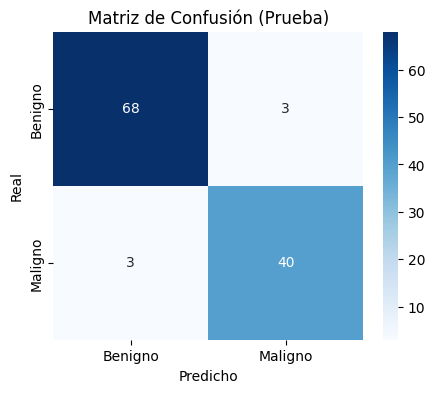

In [ ]:
#Prueba del modelo
test_predictions = clf.predict(test_data)
conf_matrix = confusion_matrix(test_label, test_predictions)
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión (Prueba)")
plt.show()

In [ ]:
# Predicción 1
print("Predicción 1:", test_predictions[1])
print("Real 1:", test_label.iloc[1])

Predicción 1: M
Real 1: M


In [ ]:
# Predicción 2
print("\nPredicción 2:", test_predictions[20])
print("Real 2:", test_label.iloc[20])


Predicción 2: B
Real 2: M


In [ ]:
# Predicción 3
print("\nPredicción 3:", test_predictions[-1])
print("Real 3:", test_label.iloc[-1])


Predicción 3: M
Real 3: M


In [ ]:
accuracy = accuracy_score(test_label, test_predictions)
print("Accuracy:", accuracy)

print("Classification Report:\n", classification_report(test_label, test_predictions, target_names=['Benigno', 'Maligno']))

Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

     Benigno       0.96      0.96      0.96        71
     Maligno       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



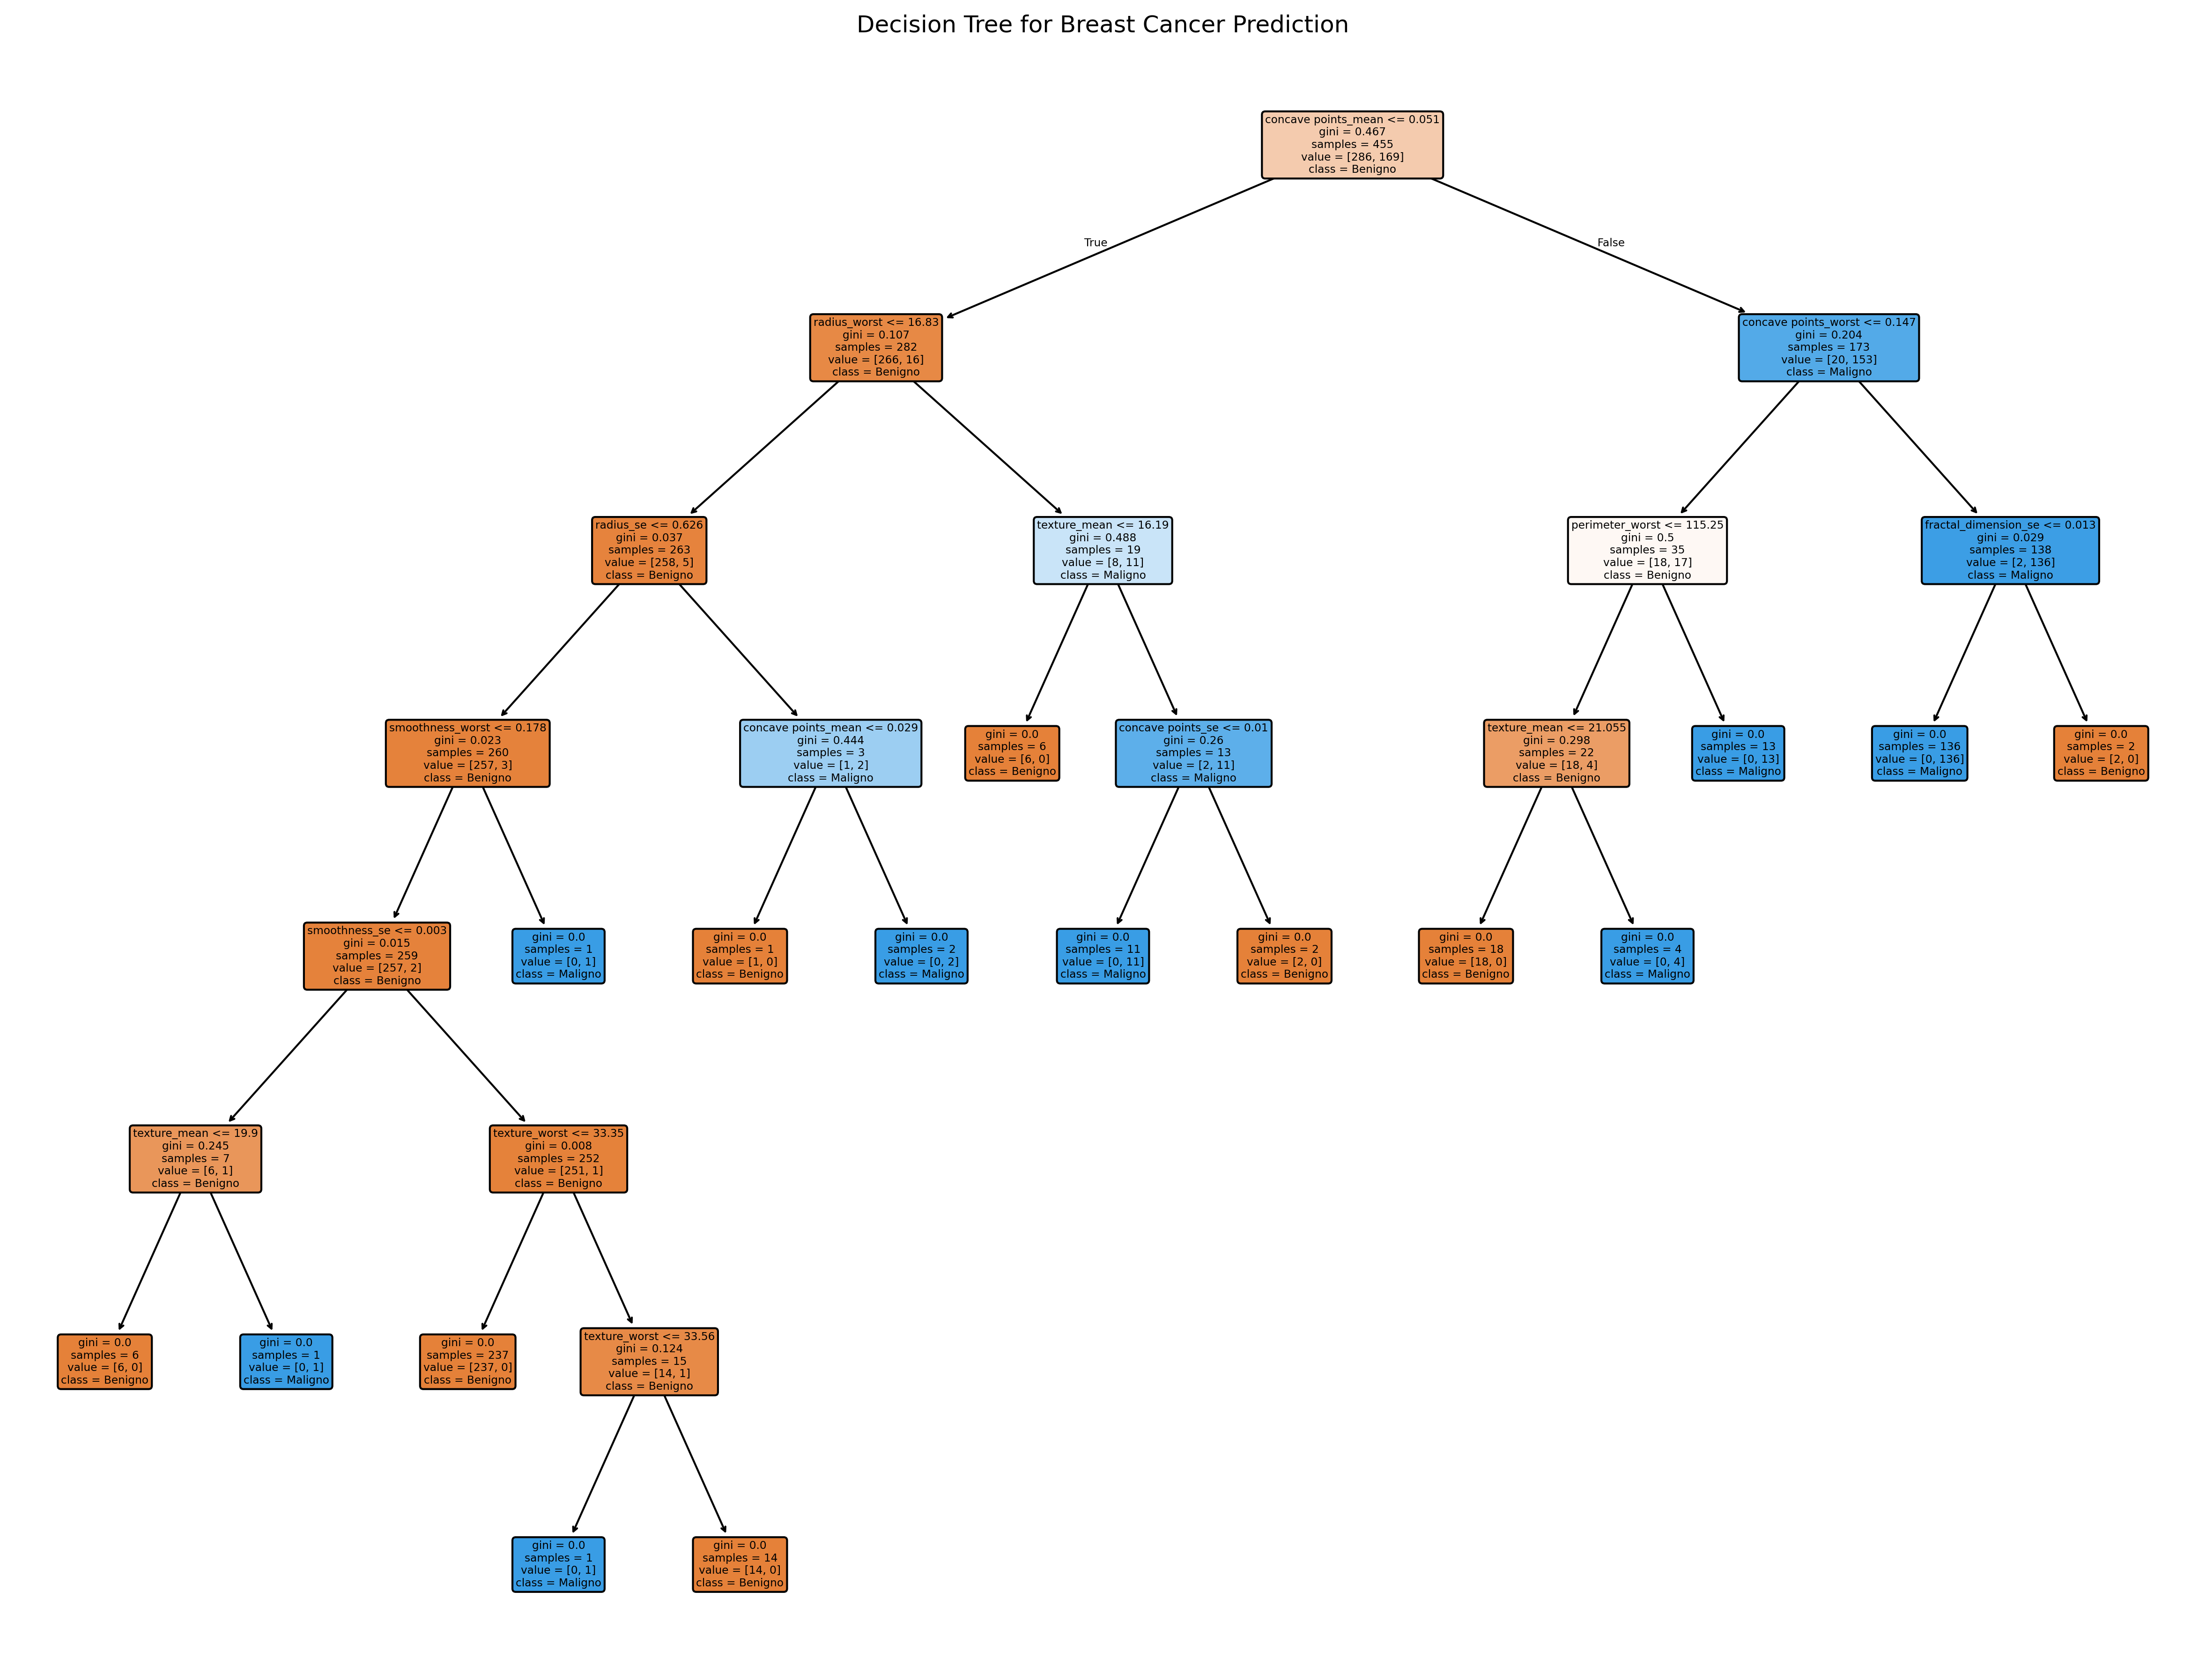

In [ ]:
plt.figure(figsize=(20, 15), dpi=300)
tree.plot_tree(clf,
               filled=True,
               feature_names=X.columns,
               class_names=['Benigno', 'Maligno'],
               rounded=True)

plt.title("Decision Tree for Breast Cancer Prediction")
plt.savefig("decision_tree.png", dpi=300)
plt.show()